In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
!pip install yfinance ta pandas-ta plotly scipy PyPortfolioOpt scikit-learn

In [1]:
# ==========================
# Data Manipulation
# ==========================
import pandas as pd
import numpy as np

# ==========================
# Market Data

# ==========================
import yfinance as yf
import requests
import io

# ==========================
# Visualization
# ==========================
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================
# Technical Analysis
# ==========================
import ta
import pandas_ta as pta

# ==========================
# Scientific Computing
# ==========================
from scipy import stats
from scipy.optimize import minimize

# ==========================
# Portfolio Optimization
# ==========================
from pypfopt import (
    EfficientFrontier,
    risk_models,
    expected_returns,
    objective_functions
)
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

# ==========================
# Machine Learning
# ==========================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score
)

# ==========================
# Utility
# ==========================
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
#pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
# ==========================
# Portfolio Configuration
# ==========================

CAPITAL = 1_000_000        # ₹10 Lakhs

RISK_FREE_RATE = 0.0687

LOOKBACK = "2y"

INTERVAL = "1d"

MAX_STOCKS = 30

MIN_MARKET_CAP = 10000      # Crores

BENCHMARK = "^NSEI"

In [3]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

urls = {
    "Nifty_50": "https://archives.nseindia.com/content/indices/ind_nifty50list.csv",
    "Nifty_Next_50": "https://archives.nseindia.com/content/indices/ind_niftynext50list.csv",
    "Nifty_Midcap_100": "https://archives.nseindia.com/content/indices/ind_niftymidcap100list.csv"
}

# Dictionary to store your dataframes
index_dataframes = {}

for name, url in urls.items():
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        index_dataframes[name] = pd.read_csv(io.StringIO(response.text))
        print(f"Successfully loaded {name}")
    else:
        print(f"Failed to load {name}")

Successfully loaded Nifty_50
Successfully loaded Nifty_Next_50
Successfully loaded Nifty_Midcap_100


In [4]:
# Display the columns of each dataframe
for name, df in index_dataframes.items():
    print(f"\n{name}")
    print(df.columns.tolist())

print("\n\n Displaying the Nifty50 dataframe")
display(index_dataframes["Nifty_50"].head())


Nifty_50
['Company Name', 'Industry', 'Symbol', 'Series', 'ISIN Code']

Nifty_Next_50
['Company Name', 'Industry', 'Symbol', 'Series', 'ISIN Code']

Nifty_Midcap_100
['Company Name', 'Industry', 'Symbol', 'Series', 'ISIN Code']


 Displaying the Nifty50 dataframe


,Company Name,Industry,Symbol,Series,ISIN Code
0,Adani Enterprises Ltd.,Metals & Mining,ADANIENT,EQ,INE423A01024
1,Adani Ports and Special Economic Zone Ltd.,Services,ADANIPORTS,EQ,INE742F01042
2,Apollo Hospitals Enterprise Ltd.,Healthcare,APOLLOHOSP,EQ,INE437A01024
3,Asian Paints Ltd.,Consumer Durables,ASIANPAINT,EQ,INE021A01026
4,Axis Bank Ltd.,Financial Services,AXISBANK,EQ,INE238A01034


In [5]:

#Ticker List

# Nifty 50
nifty50 = (
    index_dataframes["Nifty_50"]["Symbol"]
    .str.strip()
    .add(".NS")
    .tolist()
)

# Nifty Next 50
nifty_next50 = (
    index_dataframes["Nifty_Next_50"]["Symbol"]
    .str.strip()
    .add(".NS")
    .tolist()
)

# Nifty Midcap 100
nifty_midcap100 = (
    index_dataframes["Nifty_Midcap_100"]["Symbol"]
    .str.strip()
    .add(".NS")
    .tolist()
)

#Manual Addition of required stocks
manual_stocks = [
    # "BSE.NS",
    # "CAMS.NS",
    # "360ONE.NS",
    # "PGEL.NS",
    "VBL.NS",
    "SUZLON.NS",
    "EMMVEE.NS",
    "INOXWIND.NS",
]

In [6]:
# ==========================================
# Check for duplicates with index constituents
# ==========================================

index_stocks = set(nifty50 + nifty_next50 + nifty_midcap100)

already_present = sorted(set(manual_stocks) & index_stocks)
new_manual = sorted(set(manual_stocks) - index_stocks)

if already_present:
    print("⚠️ The following manual stocks are already present in the indices:")
    for stock in already_present:
        print(f"   • {stock}")

if new_manual:
    print("\n✅ New manual stocks added:")
    for stock in new_manual:
        print(f"   • {stock}")

if not manual_stocks:
    print("ℹ️ No manual stocks added.")

⚠️ The following manual stocks are already present in the indices:
   • SUZLON.NS
   • VBL.NS

✅ New manual stocks added:
   • EMMVEE.NS
   • INOXWIND.NS


In [7]:
# ==========================================
# Combined Stock Universe
# ==========================================

stock_universe = sorted(index_stocks | set(manual_stocks))

print("\n--------------------------------")
print(f"Nifty 50         : {len(nifty50)}")
print(f"Nifty Next 50    : {len(nifty_next50)}")
print(f"Nifty Midcap 100 : {len(nifty_midcap100)}")
print(f"Manual Stocks    : {len(new_manual)}")
print(f"Total Unique     : {len(stock_universe)}")


--------------------------------
Nifty 50         : 50
Nifty Next 50    : 50
Nifty Midcap 100 : 100
Manual Stocks    : 2
Total Unique     : 202


In [8]:
# Download Stock Data

# def download_stock_data(
#     ticker,
#     period="3y", # 3 years
#     interval="1d" #1 day time frame
# ):

#     try:
#         df = yf.download(
#             ticker,
#             period=period,
#             interval=interval,
#             auto_adjust=True,
#             progress=False
#         )

#         if len(df) == 0:
#             return None

#         df.dropna(inplace=True)

#         return df

#     except Exception as e:
#         print(f"{ticker}: {e}")
#         return None

# def download_stock_data(
#     ticker,
#     period="3y",
#     interval="1d"
# ):

#     df = yf.download(
#         ticker,
#         period=period,
#         interval=interval,
#         auto_adjust=True,
#         progress=False
#     )

#     # Flatten MultiIndex columns
#     if isinstance(df.columns, pd.MultiIndex):
#         df.columns = df.columns.get_level_values(0)

#     return df

def download_stock_data(
    ticker,
    period="4y",
    interval="1d"
):
    """
    Download historical OHLCV data and company metadata.
    """

    stock = yf.Ticker(ticker)

    # Download price data
    df = yf.download(
        ticker,
        period=period,
        interval=interval,
        auto_adjust=True,
        progress=False
    )

    # Flatten MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Company information
    try:
        info = stock.info

        metadata = {
            "Ticker": ticker,
            "Company": info.get("longName", np.nan),
            "Sector": info.get("sector", np.nan),
            "Industry": info.get("industry", np.nan),
            "MarketCap": info.get("marketCap", np.nan),
            "Country": info.get("country", np.nan)
        }

    except Exception:
        metadata = {
            "Ticker": ticker,
            "Company": np.nan,
            "Sector": np.nan,
            "Industry": np.nan,
            "MarketCap": np.nan,
            "Country": np.nan
        }

    return df, metadata

In [9]:
# stock_data = {}

# failed = []

# for ticker in stock_universe:

#     df = download_stock_data(ticker)

#     if df is not None:
#         stock_data[ticker] = df
#     else:
#         failed.append(ticker)

# print(f"Downloaded : {len(stock_data)}")
# print(f"Failed     : {len(failed)}")

stock_data = {}
metadata = []

for ticker in stock_universe:

    df, meta = download_stock_data(ticker)

    stock_data[ticker] = df
    metadata.append(meta)

metadata_df = pd.DataFrame(metadata)

In [10]:
# Checking Data
stock_data["COLPAL.NS"]

Price,Close,High,Low,Open,Volume
Date,,,,,
2022-08-26,1437.344482,1449.922676,1431.718577,1446.263565,204207
2022-08-29,1491.087524,1503.894411,1419.048787,1427.053091,1982748
2022-08-30,1532.206665,1536.734881,1495.661345,1501.698855,821116
2022-09-01,1535.225586,1540.668468,1512.173234,1512.173234,374367
2022-09-02,1532.801392,1551.417094,1528.410526,1539.570768,291504
...,...,...,...,...,...
2026-08-20,1910.000000,1914.900024,1875.000000,1889.800049,555231
2026-08-21,1889.000000,1907.900024,1880.099976,1907.900024,382856
2026-08-24,1879.000000,1896.800049,1873.300049,1889.000000,129484


In [11]:
# ==========================================================
# Out-of-Sample Data Split
# ==========================================================
TEST_DAYS = 252

train_data = {}
test_data = {}

for ticker, df in stock_data.items():
    # Ensure the stock has enough history to split
    if len(df) > TEST_DAYS:
        # Optimization Data: Everything except the last 20 days
        train_data[ticker] = df.iloc[:-TEST_DAYS].copy() 
        
        # Evaluation Data: Only the last 20 days
        test_data[ticker] = df.iloc[-TEST_DAYS:].copy()

In [12]:
# ==========================================================
# Trend Indicators
# ==========================================================

def add_trend_indicators(df):
    """Adds trend indicators."""

    df = df.copy()

    close = df["Close"]
    high = df["High"]
    low = df["Low"]

    # EMAs
    df["EMA20"] = ta.trend.ema_indicator(close, window=20)
    df["EMA50"] = ta.trend.ema_indicator(close, window=50)
    df["EMA100"] = ta.trend.ema_indicator(close, window=100)
    df["EMA200"] = ta.trend.ema_indicator(close, window=200)

    # SMA
    df["SMA50"] = ta.trend.sma_indicator(close, window=50)
    df["SMA200"] = ta.trend.sma_indicator(close, window=200)

    # ADX
    df["ADX"] = ta.trend.adx(high, low, close)

    return df


# ==========================================================
# Momentum Indicators
# ==========================================================

def add_momentum_indicators(df):
    """Adds momentum indicators."""

    df = df.copy()

    close = df["Close"]
    high = df["High"]
    low = df["Low"]

    # RSI
    df["RSI"] = ta.momentum.rsi(close)

    # MACD
    df["MACD"] = ta.trend.macd(close)
    df["MACD_SIGNAL"] = ta.trend.macd_signal(close)
    df["MACD_HIST"] = ta.trend.macd_diff(close)

    # Stochastic
    df["STOCH"] = ta.momentum.stoch(high, low, close)

    # Williams %R
    df["WILLIAMS_R"] = ta.momentum.williams_r(high, low, close)

    # ROC
    df["ROC"] = ta.momentum.roc(close)

    return df


# ==========================================================
# Volatility Indicators
# ==========================================================

def add_volatility_indicators(df):
    """Adds volatility indicators."""

    df = df.copy()

    close = df["Close"]
    high = df["High"]
    low = df["Low"]

    # ATR
    df["ATR"] = ta.volatility.average_true_range(high, low, close)

    # Bollinger Bands
    bb = ta.volatility.BollingerBands(close)

    df["BB_UPPER"] = bb.bollinger_hband()
    df["BB_MIDDLE"] = bb.bollinger_mavg()
    df["BB_LOWER"] = bb.bollinger_lband()
    df["BB_WIDTH"] = bb.bollinger_wband()

    return df


# ==========================================================
# Volume Indicators
# ==========================================================

def add_volume_indicators(df):
    """Adds volume indicators."""

    df = df.copy()

    close = df["Close"]
    high = df["High"]
    low = df["Low"]
    volume = df["Volume"]

    # OBV
    df["OBV"] = ta.volume.on_balance_volume(close, volume)

    # CMF
    df["CMF"] = ta.volume.chaikin_money_flow(
        high,
        low,
        close,
        volume
    )

    # Volume SMA
    df["VOL_SMA20"] = volume.rolling(20).mean()

    # Volume Ratio
    df["VOL_RATIO"] = volume / df["VOL_SMA20"]

    return df


# ==========================================================
# Return Statistics
# ==========================================================

def add_return_features(df):
    """Adds return-based features."""

    df = df.copy()

    close = df["Close"]

    # Daily Return
    df["DAILY_RETURN"] = close.pct_change()

    # Rolling Returns
    df["RET_1M"] = close.pct_change(21)
    df["RET_3M"] = close.pct_change(63)
    df["RET_6M"] = close.pct_change(126)
    # df["RET_1Y"] = close.pct_change(252)

    # Fallback to total return since listing if history < 252 days
    df["RET_1Y"] = close.pct_change(252).fillna(close / close.iloc[0] - 1)

    # Volatility
    df["VOLATILITY_20D"] = (
        df["DAILY_RETURN"]
        .rolling(20)
        .std()
        * np.sqrt(252)
    )

    return df


# ==========================================================
# Relative Strength Features
# ==========================================================

def add_relative_strength(df):
    """Adds relative strength features."""

    df = df.copy()

    close = df["Close"]

    # # 52 Week High & Low
    # df["52W_HIGH"] = close.rolling(252).max()
    # df["52W_LOW"] = close.rolling(252).min()

    # # Distance from High/Low
    # df["DIST_HIGH_%"] = (
    #     (close / df["52W_HIGH"] - 1) * 100
    # )

    # df["DIST_LOW_%"] = (
    #     (close / df["52W_LOW"] - 1) * 100
    # )

    # Use available data if less than 252 trading days exist
    df["52W_HIGH"] = close.rolling(252, min_periods=1).max()
    df["52W_LOW"] = close.rolling(252, min_periods=1).min()

    df["DIST_HIGH_%"] = ((close / df["52W_HIGH"] - 1) * 100)
    df["DIST_LOW_%"] = ((close / df["52W_LOW"] - 1) * 100)

    return df


# ==========================================================
# Master Feature Engineering
# ==========================================================

def engineer_features(df):
    """Runs every feature engineering function."""

    df = add_trend_indicators(df)
    df = add_momentum_indicators(df)
    df = add_volatility_indicators(df)
    df = add_volume_indicators(df)
    df = add_return_features(df)
    df = add_relative_strength(df)

    return df

In [13]:
# for ticker in stock_data:
#     stock_data[ticker] = engineer_features(stock_data[ticker])

for ticker in train_data:
    train_data[ticker] = engineer_features(train_data[ticker])

In [14]:
import pandas_ta as pta
#Summarize all stocks with technical indicators in 1 dataframe

def summarize_stock(ticker, df):
    """Extract latest metrics for a stock."""

    latest = df.iloc[-1]

    return {
        "Ticker": ticker,

        # Price
        "Price": latest["Close"],

        # Trend
        "EMA20": latest["EMA20"],
        "EMA50": latest["EMA50"],
        "EMA100": latest["EMA100"],
        "EMA200": latest["EMA200"],
        "ADX": latest["ADX"],

        # Momentum
        "RSI": latest["RSI"],
        "MACD": latest["MACD"],

        # Volatility
        "ATR": latest["ATR"],

        # Volume
        "Volume": latest["Volume"],
        "Volume Ratio": latest["VOL_RATIO"],

        # Returns
        "1M Return": latest["RET_1M"],
        "3M Return": latest["RET_3M"],
        "6M Return": latest["RET_6M"],
        "1Y Return": latest["RET_1Y"],

        # Relative Strength
        "52W High": latest["52W_HIGH"],
        "52W Low": latest["52W_LOW"],
        "Distance High %": latest["DIST_HIGH_%"],
        "Distance Low %": latest["DIST_LOW_%"]
    }

In [15]:
# master_df = pd.DataFrame(
#     [
#         summarize_stock(ticker, df)
#         for ticker, df in stock_data.items()
#     ]
# )

# master_df.head()

master_df = pd.DataFrame(
    [
        summarize_stock(ticker, df)
        for ticker, df in train_data.items() # <--- Changed to train_data
    ]
)

master_df.head()

,Ticker,Price,EMA20,EMA50,EMA100,EMA200,ADX,RSI,MACD,ATR,Volume,Volume Ratio,1M Return,3M Return,6M Return,1Y Return,52W High,52W Low,Distance High %,Distance Low %
0,360ONE.NS,1069.915894,1066.219499,1079.379914,1062.804503,1028.318929,25.132249,48.988188,-16.087660,30.837958,532904.0,0.673453,-0.054628,0.063050,0.203003,-0.008937,1275.312622,794.938171,-16.105598,34.591083
1,ABB.NS,4983.706543,5137.566921,5368.940537,5540.599230,5804.273863,35.092436,32.925295,-153.614284,110.295518,219900.0,0.547000,-0.111770,-0.154059,-0.026376,-0.344861,8576.601562,4819.418457,-41.891826,3.408878
2,ABCAPITAL.NS,286.350006,275.661828,263.793590,244.754841,225.602709,30.869173,60.325359,5.965485,8.442115,4034083.0,0.616430,0.066083,0.290155,0.859778,0.312870,291.299988,152.320007,-1.699273,87.992379
3,ADANIENSOL.NS,800.150024,813.481369,833.390638,842.041484,862.077417,33.442201,42.361950,-10.733891,20.272583,537046.0,0.230748,-0.072935,-0.089393,0.139815,-0.272525,1088.400024,600.750000,-26.483829,33.191848
4,ADANIENT.NS,2323.860840,2374.552492,2436.562108,2453.882148,2511.299726,35.518957,41.527271,-47.875895,59.570854,584211.0,0.615332,-0.110767,-0.086999,0.046028,-0.242489,3183.098389,2094.025146,-26.993748,10.975785


In [16]:
# ==========================================================
# Helper Function
# ==========================================================

def get_statement_value(df, possible_names, period=0, cutoff_date = "2025-08-31"):
    """
    Fetch value from financial statement.
    Handles different row names used by yfinance.
    """

    """Fetch value from financial statement as of a specific historical cutoff date.

    Filters out any financial statements published after cutoff_date.
    """
    if df is None or df.empty:
        return np.nan

    # Convert cutoff_date to pandas Timestamp
    cutoff = pd.to_datetime(cutoff_date)

    # Filter columns to only keep statement dates on or before the cutoff date
    valid_cols = [col for col in df.columns if pd.to_datetime(col) <= cutoff]

    if not valid_cols:
        return np.nan

    # Sort valid past columns descending (newest valid statement as of cutoff date comes first)
    valid_cols = sorted(valid_cols, key=lambda x: pd.to_datetime(x), reverse=True)

    # Ensure requested period offset exists in historical filtered columns
    if period >= len(valid_cols):
        return np.nan

    target_col = valid_cols[period]

    for name in possible_names:
        if name in df.index:
            try:
                val = df.loc[name, target_col]
                # If yfinance returns duplicate rows as a Series, pick the first valid value
                if isinstance(val, pd.Series):
                    val = (
                        val.dropna().iloc[0] if not val.dropna().empty else np.nan
                    )
                return float(val) if pd.notna(val) else np.nan
            except Exception:
                continue

    return np.nan


# ==========================================================
# CAGR Function
# ==========================================================

def calculate_cagr(start, end, years):

    try:
        if start <= 0 or end <= 0:
            return np.nan

        return (end/start)**(1/years)-1

    except:
        return np.nan



# ==========================================================
# Fundamental Engine
# ==========================================================

# def calculate_fundamentals(ticker):

#     stock = yf.Ticker(ticker)

#     try:

#         # Annual statements
#         income = stock.income_stmt
#         balance = stock.balance_sheet
#         cashflow = stock.cashflow


#         # Quarterly statements
#         q_income = stock.quarterly_income_stmt
#         q_balance = stock.quarterly_balance_sheet
#         q_cashflow = stock.quarterly_cashflow


#         data = {
#             "Ticker": ticker
#         }


#         # ==================================================
#         # ANNUAL FUNDAMENTALS
#         # ==================================================


#         revenue = get_statement_value(
#             income,
#             [
#                 "Total Revenue",
#                 "Operating Revenue"
#             ]
#         )

#         revenue_old = get_statement_value(
#             income,
#             [
#                 "Total Revenue",
#                 "Operating Revenue"
#             ],
#             period=3
#         )


#         net_income = get_statement_value(
#             income,
#             [
#                 "Net Income",
#                 "Net Income Common Stockholders"
#             ]
#         )


#         ebit = get_statement_value(
#             income,
#             [
#                 "EBIT",
#                 "Operating Income"
#             ]
#         )


#         interest = abs(
#             get_statement_value(
#                 income,
#                 [
#                     "Interest Expense",
#                     "Interest Expense Non Operating"
#                 ]
#             )
#         )


#         equity = get_statement_value(
#             balance,
#             [
#                 "Stockholders Equity",
#                 "Total Equity Gross Minority Interest"
#             ]
#         )


#         assets = get_statement_value(
#             balance,
#             [
#                 "Total Assets"
#             ]
#         )


#         debt = get_statement_value(
#             balance,
#             [
#                 "Total Debt",
#                 "Long Term Debt"
#             ]
#         )


#         current_assets = get_statement_value(
#             balance,
#             [
#                 "Current Assets"
#             ]
#         )


#         current_liabilities = get_statement_value(
#             balance,
#             [
#                 "Current Liabilities"
#             ]
#         )


#         cash = get_statement_value(
#             balance,
#             [
#                 "Cash Cash Equivalents And Short Term Investments",
#                 "Cash And Cash Equivalents"
#             ]
#         )


#         operating_cf = get_statement_value(
#             cashflow,
#             [
#                 "Operating Cash Flow",
#                 "Total Cash From Operating Activities"
#             ]
#         )


#         capex = abs(
#             get_statement_value(
#                 cashflow,
#                 [
#                     "Capital Expenditure",
#                     "Capital Expenditures"
#                 ]
#             )
#         )


#         # ------------------------------
#         # Profitability
#         # ------------------------------

#         data["ROE"] = net_income / equity
#         data["ROA"] = net_income / assets

#         data["Net Margin"] = net_income / revenue

#         data["Operating Margin"] = ebit / revenue


#         # ------------------------------
#         # Balance Sheet
#         # ------------------------------

#         data["Debt Equity"] = debt / equity

#         data["Current Ratio"] = (
#             current_assets /
#             current_liabilities
#         )


#         data["Cash Debt Ratio"] = (
#             cash / debt
#         )


#         # ------------------------------
#         # Cash Flow
#         # ------------------------------

#         free_cash_flow = (
#             operating_cf - capex
#         )


#         data["Free Cash Flow"] = free_cash_flow

#         data["FCF Margin"] = (
#             free_cash_flow / revenue
#         )


#         # ------------------------------
#         # Growth
#         # ------------------------------

#         data["Revenue Growth 3Y CAGR"] = calculate_cagr(
#             revenue_old,
#             revenue,
#             3
#         )



#         # ==================================================
#         # QUARTERLY FUNDAMENTALS
#         # ==================================================


#         q_revenue = get_statement_value(
#             q_income,
#             [
#                 "Total Revenue",
#                 "Operating Revenue"
#             ],
#             0
#         )


#         q_revenue_prev = get_statement_value(
#             q_income,
#             [
#                 "Total Revenue",
#                 "Operating Revenue"
#             ],
#             4
#         )


#         q_profit = get_statement_value(
#             q_income,
#             [
#                 "Net Income",
#                 "Net Income Common Stockholders"
#             ],
#             0
#         )


#         q_profit_prev = get_statement_value(
#             q_income,
#             [
#                 "Net Income",
#                 "Net Income Common Stockholders"
#             ],
#             4
#         )


#         q_operating_income = get_statement_value(
#             q_income,
#             [
#                 "Operating Income",
#                 "EBIT"
#             ],
#             0
#         )


#         # YoY Growth

#         data["Quarter Revenue Growth YoY"] = (
#             (q_revenue-q_revenue_prev)
#             /
#             q_revenue_prev
#         )


#         data["Quarter Profit Growth YoY"] = (
#             (q_profit-q_profit_prev)
#             /
#             q_profit_prev
#         )


#         data["Quarter Operating Margin"] = (
#             q_operating_income/q_revenue
#         )


#         return data


#     except Exception as e:

#         print(
#             f"{ticker} failed : {e}"
#         )

#         return {
#             "Ticker": ticker
#         }

def calculate_fundamentals(ticker, historical_price, cutoff_date="2025-08-31"):
    stock = yf.Ticker(ticker)

    try:
        # Annual statements
        income = stock.income_stmt
        balance = stock.balance_sheet
        cashflow = stock.cashflow

        # Quarterly statements
        q_income = stock.quarterly_income_stmt
        q_balance = stock.quarterly_balance_sheet
        q_cashflow = stock.quarterly_cashflow

        data = {"Ticker": ticker}

        # ==================================================
        # ANNUAL FUNDAMENTALS (as of cutoff_date)
        # ==================================================

        revenue = get_statement_value(
            income,
            ["Total Revenue", "Operating Revenue"],
            period=0,
            cutoff_date=cutoff_date,
        )

        revenue_old = get_statement_value(
            income,
            ["Total Revenue", "Operating Revenue"],
            period=3,
            cutoff_date=cutoff_date,
        )

        net_income = get_statement_value(
            income,
            ["Net Income", "Net Income Common Stockholders"],
            period=0,
            cutoff_date=cutoff_date,
        )

        ebit = get_statement_value(
            income,
            ["EBIT", "Operating Income"],
            period=0,
            cutoff_date=cutoff_date,
        )

        interest_val = get_statement_value(
            income,
            ["Interest Expense", "Interest Expense Non Operating"],
            period=0,
            cutoff_date=cutoff_date,
        )
        interest = abs(interest_val) if pd.notna(interest_val) else np.nan

        equity = get_statement_value(
            balance,
            ["Stockholders Equity", "Total Equity Gross Minority Interest"],
            period=0,
            cutoff_date=cutoff_date,
        )

        assets = get_statement_value(
            balance, ["Total Assets"], period=0, cutoff_date=cutoff_date
        )

        debt = get_statement_value(
            balance,
            ["Total Debt", "Long Term Debt"],
            period=0,
            cutoff_date=cutoff_date,
        )

        current_assets = get_statement_value(
            balance, ["Current Assets"], period=0, cutoff_date=cutoff_date
        )

        current_liabilities = get_statement_value(
            balance, ["Current Liabilities"], period=0, cutoff_date=cutoff_date
        )

        cash = get_statement_value(
            balance,
            [
                "Cash Cash Equivalents And Short Term Investments",
                "Cash And Cash Equivalents",
            ],
            period=0,
            cutoff_date=cutoff_date,
        )

        operating_cf = get_statement_value(
            cashflow,
            ["Operating Cash Flow", "Total Cash From Operating Activities"],
            period=0,
            cutoff_date=cutoff_date,
        )

        capex_val = get_statement_value(
            cashflow,
            ["Capital Expenditure", "Capital Expenditures"],
            period=0,
            cutoff_date=cutoff_date,
        )
        capex = abs(capex_val) if pd.notna(capex_val) else np.nan

        # ------------------------------
        # Fetch Historical Shares Outstanding
        # ------------------------------
        shares_out = get_statement_value(
            income, ["Basic Average Shares", "Diluted Average Shares"], 
            period=0, cutoff_date=cutoff_date
        )

        # ------------------------------
        # Profitability
        # ------------------------------
        data["ROE"] = net_income / equity if equity else np.nan
        data["ROA"] = net_income / assets if assets else np.nan
        data["Net Margin"] = net_income / revenue if revenue else np.nan
        data["Operating Margin"] = ebit / revenue if revenue else np.nan

        # ------------------------------
        # Balance Sheet
        # ------------------------------
        data["Debt Equity"] = debt / equity if equity else np.nan
        data["Current Ratio"] = (
            current_assets / current_liabilities
            if current_liabilities
            else np.nan
        )
        data["Cash Debt Ratio"] = cash / debt if debt else np.nan

        # ------------------------------
        # Cash Flow
        # ------------------------------
        free_cash_flow = (
            (operating_cf - capex)
            if pd.notna(operating_cf) and pd.notna(capex)
            else np.nan
        )
        data["Free Cash Flow"] = free_cash_flow
        data["FCF Margin"] = (
            free_cash_flow / revenue if revenue else np.nan
        )

        # ------------------------------
        # Growth
        # ------------------------------
        data["Revenue Growth 3Y CAGR"] = calculate_cagr(revenue_old, revenue, 3)

        # ==================================================
        # QUARTERLY FUNDAMENTALS (as of cutoff_date)
        # ==================================================

        # period=0: Most recent available quarter on/before cutoff_date
        q_revenue = get_statement_value(
            q_income,
            ["Total Revenue", "Operating Revenue"],
            period=0,
            cutoff_date=cutoff_date,
        )

        # period=4: Corresponding quarter from 1 year prior (4 quarters ago)
        q_revenue_prev = get_statement_value(
            q_income,
            ["Total Revenue", "Operating Revenue"],
            period=4,
            cutoff_date=cutoff_date,
        )

        q_profit = get_statement_value(
            q_income,
            ["Net Income", "Net Income Common Stockholders"],
            period=0,
            cutoff_date=cutoff_date,
        )

        q_profit_prev = get_statement_value(
            q_income,
            ["Net Income", "Net Income Common Stockholders"],
            period=4,
            cutoff_date=cutoff_date,
        )

        q_operating_income = get_statement_value(
            q_income,
            ["Operating Income", "EBIT"],
            period=0,
            cutoff_date=cutoff_date,
        )

        # YoY Growth
        data["Quarter Revenue Growth YoY"] = (
            (q_revenue - q_revenue_prev) / q_revenue_prev
            if q_revenue_prev
            else np.nan
        )

        data["Quarter Profit Growth YoY"] = (
            (q_profit - q_profit_prev) / q_profit_prev
            if q_profit_prev
            else np.nan
        )

        data["Quarter Operating Margin"] = (
            q_operating_income / q_revenue if q_revenue else np.nan
        )

        if shares_out and historical_price:
            eps = net_income / shares_out if net_income else np.nan
            bvps = equity / shares_out if equity else np.nan

            data["PE"] = historical_price / eps if eps > 0 else np.nan  # Avoid negative P/E
            data["Price to Book"] = historical_price / bvps if bvps > 0 else np.nan
        else:
            data["PE"] = np.nan
            data["Price to Book"] = np.nan
        return data

    except Exception as e:
        print(f"{ticker} failed : {e}")
        return {"Ticker": ticker}

In [17]:
# fundamentals = []

# for ticker in stock_universe:

#     result = calculate_fundamentals(ticker)

#     fundamentals.append(result)


# fundamental_df = pd.DataFrame(fundamentals)

# fundamental_df.head()

# # Backtest cutoff date
# BACKTEST_CUTOFF = "2025-08-31"

# fundamentals = []
# for ticker in stock_universe:
#     result = calculate_fundamentals(ticker, cutoff_date=BACKTEST_CUTOFF)
#     fundamentals.append(result)

# fundamental_df = pd.DataFrame(fundamentals)
# fundamental_df.head()

BACKTEST_CUTOFF = "2025-08-31"
fundamentals = []

for ticker in stock_universe:
    # Safely get the historical price at the split boundary
    if ticker in train_data and not train_data[ticker].empty:
        hist_price = train_data[ticker]["Close"].iloc[-1]
    else:
        hist_price = np.nan
        
    result = calculate_fundamentals(ticker, historical_price=hist_price, cutoff_date=BACKTEST_CUTOFF)
    fundamentals.append(result)

fundamental_df = pd.DataFrame(fundamentals)
fundamental_df.head()

,Ticker,ROE,ROA,Net Margin,Operating Margin,Debt Equity,Current Ratio,Cash Debt Ratio,Free Cash Flow,FCF Margin,Revenue Growth 3Y CAGR,Quarter Revenue Growth YoY,Quarter Profit Growth YoY,Quarter Operating Margin,PE,Price to Book
0,360ONE.NS,0.143714,0.051359,0.385268,0.847657,1.560649,1.206527,0.696669,-2.517410e+10,-0.955261,NaN,NaN,NaN,0.428679,39.422104,5.665521
1,ABB.NS,0.264528,0.151044,0.154839,0.209193,0.007332,2.040706,106.062066,1.117850e+10,0.092479,NaN,NaN,NaN,0.125727,56.425870,14.926211
2,ABCAPITAL.NS,0.109656,0.011941,0.077228,0.337325,4.600326,NaN,0.154980,-2.839228e+11,-0.658006,NaN,NaN,NaN,0.432399,22.378057,2.453899
3,ADANIENSOL.NS,0.048032,0.014332,0.044962,0.178580,1.809209,1.369238,0.138826,-3.336300e+09,-0.014152,NaN,NaN,NaN,0.271254,88.429078,4.247386
4,ADANIENT.NS,0.141094,0.035829,0.072653,0.157263,1.818036,0.864109,0.074373,-2.536604e+11,-0.259602,NaN,NaN,NaN,0.092269,38.657582,5.454353


In [18]:
master_df = master_df.merge(
    fundamental_df,
    on="Ticker",
    how="left"
)
master_df = master_df.merge(
    metadata_df,
    on="Ticker",
    how="left"
)

In [19]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Ticker                      195 non-null    object 
 1   Price                       195 non-null    float64
 2   EMA20                       195 non-null    float64
 3   EMA50                       194 non-null    float64
 4   EMA100                      194 non-null    float64
 5   EMA200                      192 non-null    float64
 6   ADX                         195 non-null    float64
 7   RSI                         195 non-null    float64
 8   MACD                        195 non-null    float64
 9   ATR                         195 non-null    float64
 10  Volume                      195 non-null    float64
 11  Volume Ratio                195 non-null    float64
 12  1M Return                   195 non-null    float64
 13  3M Return                   194 non

**Now Comes the part of using technical and fundamental analysis to make the portfolio**

In [20]:
# Returns a dataframe containing ONLY the rows with NaN values
df_with_nans = master_df[master_df.isna().any(axis=1)]

print(df_with_nans)

            Ticker        Price        EMA20        EMA50       EMA100       EMA200        ADX        RSI        MACD         ATR      Volume  \
0        360ONE.NS  1069.915894  1066.219499  1079.379914  1062.804503  1028.318929  25.132249  48.988188  -16.087660   30.837958    532904.0   
1           ABB.NS  4983.706543  5137.566921  5368.940537  5540.599230  5804.273863  35.092436  32.925295 -153.614284  110.295518    219900.0   
2     ABCAPITAL.NS   286.350006   275.661828   263.793590   244.754841   225.602709  30.869173  60.325359    5.965485    8.442115   4034083.0   
3    ADANIENSOL.NS   800.150024   813.481369   833.390638   842.041484   862.077417  33.442201  42.361950  -10.733891   20.272583    537046.0   
4      ADANIENT.NS  2323.860840  2374.552492  2436.562108  2453.882148  2511.299726  35.518957  41.527271  -47.875895   59.570854    584211.0   
..             ...          ...          ...          ...          ...          ...        ...        ...         ...         ... 

In [21]:
# ==========================================================
# Filtering Stocks
# ==========================================================

# Make a copy
df = master_df.copy()

# Remove stocks without enough technical history
df = df.dropna(
    subset=[
        "Price",
        "EMA200",
        "RSI",
        "ADX", # Added ADX to the subset for dropping NaNs
        "1M Return",
        "3M Return",
        "6M Return"
    ]
)

print("Stocks remaining:", len(df))

Stocks remaining: 192


In [22]:
#EMA
df["Trend_Signal"] = (
    (df["Price"] > df["EMA20"]).astype(int) +
    (df["Price"] > df["EMA50"]).astype(int) +
    (df["Price"] > df["EMA100"]).astype(int) +
    (df["Price"] > df["EMA200"]).astype(int)
)

In [23]:
#Momentum

df["Momentum_Signal"] = (
    (df["RSI"] > 50).astype(int) +
    (df["MACD"] > 0).astype(int) +
    (df["1M Return"] > 0).astype(int) +
    (df["3M Return"] > 0).astype(int) +
    (df["6M Return"] > 0).astype(int)
)

In [24]:
#Volume

df["Volume_Signal"] = (
    df["Volume Ratio"] > 1
).astype(int)

In [25]:
# ==========================================================
# Normalizing Technical Signals
# ==========================================================

df["Trend_Score"] = df["Trend_Signal"] / 4
df["Momentum_Score"] = df["Momentum_Signal"] / 5
df["Volume_Score"] = df["Volume_Signal"] / 1

#Percentile Ranking System
def percentile_rank(series, higher_is_better=True):
    if higher_is_better:
        return series.rank(pct=True)
    else:
        return 1 - series.rank(pct=True)

# Relative strength
df["Return_1M_Score"] = percentile_rank(df["1M Return"])
df["Return_3M_Score"] = percentile_rank(df["3M Return"])
df["Return_6M_Score"] = percentile_rank(df["6M Return"])
df["Return_1Y_Score"] = percentile_rank(df["1Y Return"])

# Trend strength
df["ADX_Score"] = percentile_rank(df["ADX"])

# Volume
df["Volume_Ratio_Score"] = percentile_rank(df["Volume Ratio"])

In [26]:
# ==========================================================
# Category Score
# ==========================================================

# Technical Score
df["Technical_Score"] = (
    0.30 * df["Trend_Score"] +
    0.20 * df["Momentum_Score"] +
    0.20 * df["Return_3M_Score"] +
    0.20 * df["Return_6M_Score"] +
    0.10 * df["Volume_Ratio_Score"]
)

# Fundamental Score
df["ROE_Score"] = percentile_rank(df["ROE"])
df["Margin_Score"] = percentile_rank(df["Net Margin"])

#This is currently NaN
#df["Growth_Score"] = percentile_rank(df["Quarter Revenue Growth YoY"])


df["Debt_Score"] = percentile_rank(df["Debt Equity"], higher_is_better=False)

df["Fundamental_Score"] = (
    0.40 * df["ROE_Score"] +
    0.35 * df["Margin_Score"] +
    #0.25 * df["Growth_Score"] +
    0.25 * df["Debt_Score"]
)

# Valuation Score
df["PE_Score"] = percentile_rank(df["PE"], higher_is_better=False)
df["PB_Score"] = percentile_rank(df["Price to Book"], higher_is_better=False)

df["Valuation_Score"] = (
    0.6 * df["PE_Score"] +
    0.4 * df["PB_Score"]
)



#Combining all 3 above scores
df["Total_Score"] = (
    0.40 * df["Technical_Score"] +
    0.40 * df["Fundamental_Score"]+ 
    0.20 * df["Valuation_Score"])

In [27]:
ranking = (
    df.sort_values("Total_Score", ascending=False)
      .reset_index(drop=True)
)

ranking[[
    "Ticker",
    "Technical_Score",
    "Fundamental_Score",
    "Valuation_Score",
    "Total_Score"
]].head(30)

,Ticker,Technical_Score,Fundamental_Score,Valuation_Score,Total_Score
0,INDIANB.NS,0.869792,0.619341,0.932431,0.782139
1,HEROMOTOCO.NS,0.935937,0.652402,0.676057,0.770547
2,MOTILALOFS.NS,0.862083,0.676025,0.683442,0.751932
3,EICHERMOT.NS,0.838542,0.789244,0.495472,0.750209
4,CUMMINSIND.NS,0.944792,0.793221,0.271646,0.749534
5,GODFRYPHLP.NS,0.948958,0.720651,0.376040,0.743052
6,NATIONALUM.NS,0.528854,0.869035,0.905096,0.740175
7,CIPLA.NS,0.803125,0.687827,0.689657,0.734312
8,ADANIPOWER.NS,0.799479,0.644990,0.748906,0.727569
9,HYUNDAI.NS,0.915625,0.675393,0.435489,0.723505


In [28]:
top50 = ranking.head(50).copy()

In [29]:
top50["Sector"].value_counts()

Sector
Financial Services        15
Consumer Cyclical          8
Industrials                8
Basic Materials            6
Healthcare                 5
Consumer Defensive         3
Technology                 2
Utilities                  1
Communication Services     1
Energy                     1
Name: count, dtype: int64

In [30]:
MAX_PER_SECTOR = 2

selected = (
    top50
    .groupby("Sector", group_keys=False)
    .head(MAX_PER_SECTOR)
)

selected

,Ticker,Price,EMA20,EMA50,EMA100,EMA200,ADX,RSI,MACD,ATR,Volume,Volume Ratio,1M Return,3M Return,6M Return,1Y Return,52W High,52W Low,Distance High %,Distance Low %,ROE,ROA,Net Margin,Operating Margin,Debt Equity,Current Ratio,Cash Debt Ratio,Free Cash Flow,FCF Margin,Revenue Growth 3Y CAGR,Quarter Revenue Growth YoY,Quarter Profit Growth YoY,Quarter Operating Margin,PE,Price to Book,Company,Sector,Industry,MarketCap,Country,Trend_Signal,Momentum_Signal,Volume_Signal,Trend_Score,Momentum_Score,Volume_Score,Return_1M_Score,Return_3M_Score,Return_6M_Score,Return_1Y_Score,ADX_Score,Volume_Ratio_Score,Technical_Score,ROE_Score,Margin_Score,Debt_Score,Fundamental_Score,PE_Score,PB_Score,Valuation_Score,Total_Score
0,INDIANB.NS,656.269714,642.831119,624.530398,598.667804,565.772056,27.252623,62.260251,10.932689,12.889201,805749.0,0.550934,0.073430,0.155564,0.328156,0.230774,662.193481,454.260864,-0.894567,44.469789,0.157475,0.012840,0.319720,NaN,0.466689,NaN,1.646818,1.685646e+11,0.478565,NaN,NaN,NaN,NaN,7.849523,1.236101,Indian Bank,Financial Services,Banks - Regional,1.197451e+12,India,4,5,0,1.00,1.0,0.0,0.916667,0.875000,0.838542,0.817708,0.645833,0.270833,0.869792,0.526042,0.869792,0.417989,0.619341,0.936508,0.926316,0.932431,0.782139
1,HEROMOTOCO.NS,4831.281250,4558.250039,4323.069284,4167.318180,4125.656139,32.222880,67.489907,194.462980,122.781353,1357460.0,1.350214,0.162654,0.163801,0.308794,-0.008319,5750.743164,3326.350830,-15.988576,45.242685,0.227193,0.154224,0.107546,0.147478,0.036318,1.796940,10.269313,3.440960e+10,0.084519,NaN,NaN,NaN,0.124108,22.065023,5.013027,Hero MotoCorp Limited,Consumer Cyclical,Auto Manufacturers,1.119790e+12,India,4,5,1,1.00,1.0,1.0,0.989583,0.885417,0.822917,0.541667,0.791667,0.942708,0.935937,0.770833,0.401042,0.814815,0.652402,0.751323,0.563158,0.676057,0.770547
2,MOTILALOFS.NS,921.809570,921.243001,888.856775,839.915407,794.130287,17.734203,52.034775,11.159910,26.401380,605404.0,0.586333,-0.002148,0.187009,0.512574,0.382391,1013.546753,561.120911,-9.051105,64.280025,0.225793,0.073606,0.388961,0.696481,1.329648,1.232270,0.815081,9.304800e+09,0.144673,NaN,NaN,NaN,1.015551,22.038977,4.976256,Motilal Oswal Financial Services Limited,Financial Services,Capital Markets,6.262325e+11,India,4,4,0,1.00,0.8,0.0,0.619792,0.906250,0.942708,0.911458,0.286458,0.322917,0.862083,0.765625,0.916667,0.195767,0.676025,0.756614,0.573684,0.683442,0.751932
3,EICHERMOT.NS,5863.102539,5669.839233,5530.747305,5396.616636,5174.585963,27.148592,71.232797,117.844145,98.445280,273421.0,0.558872,0.102880,0.105725,0.264714,0.228960,5913.079102,4483.016602,-0.845187,30.784761,0.222311,0.174224,0.255388,0.322977,0.021512,1.630220,8.560518,2.940590e+10,0.158623,NaN,NaN,NaN,0.203153,33.938208,7.544831,Eicher Motors Limited,Consumer Cyclical,Auto Manufacturers,2.205782e+12,India,4,5,0,1.00,1.0,0.0,0.947917,0.786458,0.765625,0.812500,0.635417,0.281250,0.838542,0.760417,0.781250,0.846561,0.789244,0.566138,0.389474,0.495472,0.750209
4,CUMMINSIND.NS,3866.206299,3672.558250,3495.448803,3325.663923,3206.801819,45.707544,76.537600,100.929206,81.981820,558580.0,0.801579,0.082845,0.342437,0.452512,0.038896,3866.206299,2624.469482,0.000000,47.313822,0.264493,0.196680,0.195703,0.255269,0.003923,3.103211,116.434255,1.456550e+10,0.142530,NaN,NaN,NaN,0.201339,53.587227,14.173465,Cummins India Limited,Industrials,Specialty Industrial Machinery,1.441440e+12,India,4,5,0,1.00,1.0,0.0,0.932292,0.979167,0.916667,0.609375,0.984375,0.656250,0.944792,0.817708,0.666667,0.931217,0.793221,0.354497,0.147368,0.271646,0.749534
5,GODFRYPHLP.NS,3451.754883,3225.686041,3016.759379,2771.486121,2424.145773,41.830625,59.289673,144.258264,198.265239,1400091.0,0.866816,0.132057,0.283463,0.509409,0.846575,3619.344727,1375.848022,-4.630392,150.881989,0.204359,0.153827,0.192173,0.265910,0.033833,2.097099,1.102209,-6.050000e+08,-0.010845,NaN,NaN,NaN,0.209924,50.071628,10.232583,Godfrey Phillips India Limited,Consumer Defensive,Tobacco,3.358755e+11,India,4,5,0,1.00,1.

In [31]:
prices = pd.DataFrame({
    ticker: train_data[ticker]["Close"]
    for ticker in selected["Ticker"]
})

In [32]:
returns = prices.pct_change().dropna()

In [33]:
corr = returns.corr()

In [34]:
def remove_highly_correlated_stocks(
    ranking_df,
    returns_df,
    threshold=0.85
):
    """
    Removes highly correlated stocks while keeping
    the stock with the higher Total_Score.
    """

    corr = returns_df.corr().abs()

    # Upper triangle only
    upper = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )

    # Total Score lookup
    score_dict = (
        ranking_df
        .set_index("Ticker")["Total_Score"]
        .to_dict()
    )

    remove = set()

    for col in upper.columns:

        high_corr = upper.index[
            upper[col] > threshold
        ]

        for other in high_corr:

            if other in remove or col in remove:
                continue

            score_other = score_dict.get(other, -1)
            score_col = score_dict.get(col, -1)

            if score_other >= score_col:
                remove.add(col)
            else:
                remove.add(other)

    filtered = ranking_df[
        ~ranking_df["Ticker"].isin(remove)
    ].copy()

    return filtered, remove

In [35]:
filtered_ranking, removed = remove_highly_correlated_stocks(
    selected,
    returns,
    threshold=0.85
)

print(f"Removed {len(removed)} stocks")
print(filtered_ranking.head(30))

Removed 0 stocks
           Ticker        Price        EMA20        EMA50       EMA100       EMA200        ADX        RSI        MACD         ATR      Volume  \
0      INDIANB.NS   656.269714   642.831119   624.530398   598.667804   565.772056  27.252623  62.260251   10.932689   12.889201    805749.0   
1   HEROMOTOCO.NS  4831.281250  4558.250039  4323.069284  4167.318180  4125.656139  32.222880  67.489907  194.462980  122.781353   1357460.0   
2   MOTILALOFS.NS   921.809570   921.243001   888.856775   839.915407   794.130287  17.734203  52.034775   11.159910   26.401380    605404.0   
3    EICHERMOT.NS  5863.102539  5669.839233  5530.747305  5396.616636  5174.585963  27.148592  71.232797  117.844145   98.445280    273421.0   
4   CUMMINSIND.NS  3866.206299  3672.558250  3495.448803  3325.663923  3206.801819  45.707544  76.537600  100.929206   81.981820    558580.0   
5   GODFRYPHLP.NS  3451.754883  3225.686041  3016.759379  2771.486121  2424.145773  41.830625  59.289673  144.258264  1

In [36]:
final_tickers = filtered_ranking["Ticker"].tolist()

In [37]:
prices = pd.DataFrame()

for ticker in final_tickers:
    prices[ticker] = train_data[ticker]["Close"]

prices = prices.dropna()

In [38]:
prices.head()

,INDIANB.NS,HEROMOTOCO.NS,MOTILALOFS.NS,EICHERMOT.NS,CUMMINSIND.NS,GODFRYPHLP.NS,NATIONALUM.NS,CIPLA.NS,ADANIPOWER.NS,VEDL.NS,ZYDUSLIFE.NS,GVT&D.NS,HINDUNILVR.NS,WAAREEENER.NS,MPHASIS.NS,BHARTIARTL.NS,COALINDIA.NS
Date,,,,,,,,,,,,,,,,,
2024-10-28,526.486267,4577.704590,904.140381,4611.927246,3322.592285,2024.014404,205.755157,1473.439453,119.639999,430.252380,994.009766,1659.593994,2474.850830,2337.588623,2876.704102,1629.057739,387.020447
2024-10-29,554.698547,4447.326660,932.931580,4785.339355,3376.185303,2054.536865,209.855728,1448.345459,118.459999,433.141205,989.959900,1680.703003,2447.803711,2378.865479,2885.917969,1603.348999,390.438019
2024-10-30,561.477112,4560.519531,909.504944,4757.104980,3412.384033,2051.888672,208.816803,1390.217529,118.410004,429.656219,973.315674,1694.941528,2454.817627,2440.281006,2871.118164,1599.676147,393.592712
2024-10-31,565.725708,4635.068359,922.596313,4781.919922,3401.791748,2139.854736,209.000702,1521.078857,118.540001,425.575226,989.021484,1778.232422,2429.164062,2720.573975,2749.427490,1579.354004,396.134003
2024-11-01,558.803833,4663.818848,961.329041,4839.512207,3400.965576,2164.046631,210.683197,1528.724609,119.470001,428.601593,991.737854,1795.557739,2438.051758,2888.479736,2763.367676,1583.124634,397.974243


In [40]:
##---------------------------------
##CAPM Model
##---------------------------------

# from pypfopt import expected_returns, risk_models, EfficientFrontier

# mu = expected_returns.capm_return(prices,risk_free_rate=RISK_FREE_RATE)

# S = risk_models.CovarianceShrinkage(prices).ledoit_wolf()

# ef = EfficientFrontier(mu, S)

# weights = ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)

# cleaned_weights = ef.clean_weights()

# weights_df = (
#     pd.DataFrame.from_dict(
#         cleaned_weights,
#         orient="index",
#         columns=["Weight"]
#     )
#     .sort_values("Weight", ascending=False)
# )

# weights_df.head(30)

# ==========================================================
# Portfolio Optimization: HRP Prior + Black-Litterman (Total_Score Views)
# ==========================================================
from pypfopt import (
    HRPOpt,
    risk_models,
    black_litterman,
    EfficientFrontier,
    objective_functions
)

# 1. Compute historical returns & covariance from training prices
returns = prices.pct_change().dropna()
S = risk_models.CovarianceShrinkage(prices).ledoit_wolf()

# 2. Step 1: Generate HRP Baseline Weights (Crash-Resistant Prior)
hrp = HRPOpt(returns=returns)
hrp_weights = hrp.optimize()
hrp_weights_series = pd.Series(hrp_weights)

# 3. Step 2: Reverse-engineer Market Implied Returns
delta = 2.5  # Risk aversion parameter
prior_returns = black_litterman.market_implied_prior_returns(hrp_weights_series, delta, S)

# 4. Step 3: Map Total_Score to Expected Return Views
# (e.g., Score 0.80 -> 32% expected annual return)
viewdict = {}
for _, row in filtered_ranking.iterrows():
    ticker = row["Ticker"]
    score = row["Total_Score"]
    viewdict[ticker] = score * 0.40

# 5. Step 4: Blend via Black-Litterman Model
bl = black_litterman.BlackLittermanModel(S, pi=prior_returns, absolute_views=viewdict)
bl_returns = bl.bl_returns()
bl_S = bl.bl_cov()

# 6. Step 5: Mean-Variance Optimization on BL Posterior
ef = EfficientFrontier(bl_returns, bl_S)
ef.add_objective(objective_functions.L2_reg, gamma=0.1)  # Prevents extreme single-stock concentration
weights = ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)
cleaned_weights = ef.clean_weights()

# 7. Final Weights DataFrame
weights_df = (
    pd.DataFrame.from_dict(cleaned_weights, orient="index", columns=["Weight"])
    .sort_values("Weight", ascending=False)
)

display(weights_df)

,Weight
HINDUNILVR.NS,0.10719
CIPLA.NS,0.09432
HEROMOTOCO.NS,0.08952
EICHERMOT.NS,0.08925
BHARTIARTL.NS,0.07786
ZYDUSLIFE.NS,0.07749
INDIANB.NS,0.06840
VEDL.NS,0.05966
CUMMINSIND.NS,0.05775
MOTILALOFS.NS,0.04503


In [41]:
performance = ef.portfolio_performance(verbose=True,risk_free_rate=RISK_FREE_RATE)

Expected annual return: 23.7%
Annual volatility: 16.4%
Sharpe Ratio: 1.03


In [42]:
portfolio = (
    filtered_ranking.merge(
        weights_df,
        left_on="Ticker",
        right_index=True
    )
    .sort_values("Weight", ascending=False)
)

portfolio.head(30)

,Ticker,Price,EMA20,EMA50,EMA100,EMA200,ADX,RSI,MACD,ATR,Volume,Volume Ratio,1M Return,3M Return,6M Return,1Y Return,52W High,52W Low,Distance High %,Distance Low %,ROE,ROA,Net Margin,Operating Margin,Debt Equity,Current Ratio,Cash Debt Ratio,Free Cash Flow,FCF Margin,Revenue Growth 3Y CAGR,Quarter Revenue Growth YoY,Quarter Profit Growth YoY,Quarter Operating Margin,PE,Price to Book,Company,Sector,Industry,MarketCap,Country,Trend_Signal,Momentum_Signal,Volume_Signal,Trend_Score,Momentum_Score,Volume_Score,Return_1M_Score,Return_3M_Score,Return_6M_Score,Return_1Y_Score,ADX_Score,Volume_Ratio_Score,Technical_Score,ROE_Score,Margin_Score,Debt_Score,Fundamental_Score,PE_Score,PB_Score,Valuation_Score,Total_Score,Weight
22,HINDUNILVR.NS,2583.113281,2495.571096,2423.517218,2372.057239,2358.730381,42.193223,65.305797,48.745225,53.525435,1223445.0,0.726521,0.073253,0.110044,0.140876,-0.022744,2909.856934,2096.918701,-11.228856,23.186144,0.215558,0.133312,0.175804,0.244482,0.033359,1.333434,7.285194,1.061100e+11,0.175177,NaN,NaN,NaN,0.212722,56.993712,12.285455,Hindustan Unilever Limited,Consumer Defensive,Household & Personal Products,4.748524e+12,India,4,5,0,1.00,1.0,0.0,0.911458,0.807292,0.536458,0.515625,0.968750,0.593750,0.828125,0.744792,0.630208,0.825397,0.724839,0.333333,0.215789,0.286316,0.678449,0.10719
7,CIPLA.NS,1577.996094,1524.099363,1501.341431,1485.651239,1470.075703,19.354885,66.333747,19.461722,28.215444,1574526.0,0.897343,0.080964,0.084635,0.091659,0.030051,1647.284058,1357.330566,-4.206194,16.257317,0.169027,0.141025,0.194233,0.252891,0.014048,4.246661,24.211598,3.456780e+10,0.127343,NaN,NaN,NaN,0.223111,24.168980,4.085198,Cipla Limited,Healthcare,Drug Manufacturers - Specialty & Generic,1.133176e+12,India,4,5,0,1.00,1.0,0.0,0.927083,0.755208,0.390625,0.593750,0.348958,0.739583,0.803125,0.588542,0.661458,0.883598,0.687827,0.724868,0.636842,0.689657,0.734312,0.09432
1,HEROMOTOCO.NS,4831.281250,4558.250039,4323.069284,4167.318180,4125.656139,32.222880,67.489907,194.462980,122.781353,1357460.0,1.350214,0.162654,0.163801,0.308794,-0.008319,5750.743164,3326.350830,-15.988576,45.242685,0.227193,0.154224,0.107546,0.147478,0.036318,1.796940,10.269313,3.440960e+10,0.084519,NaN,NaN,NaN,0.124108,22.065023,5.013027,Hero MotoCorp Limited,Consumer Cyclical,Auto Manufacturers,1.119790e+12,India,4,5,1,1.00,1.0,1.0,0.989583,0.885417,0.822917,0.541667,0.791667,0.942708,0.935937,0.770833,0.401042,0.814815,0.652402,0.751323,0.563158,0.676057,0.770547,0.08952
3,EICHERMOT.NS,5863.102539,5669.839233,5530.747305,5396.616636,5174.585963,27.148592,71.232797,117.844145,98.445280,273421.0,0.558872,0.102880,0.105725,0.264714,0.228960,5913.079102,4483.016602,-0.845187,30.784761,0.222311,0.174224,0.255388,0.322977,0.021512,1.630220,8.560518,2.940590e+10,0.158623,NaN,NaN,NaN,0.203153,33.938208,7.544831,Eicher Motors Limited,Consumer Cyclical,Auto Manufacturers,2.205782e+12,India,4,5,0,1.00,1.0,0.0,0.947917,0.786458,0.765625,0.812500,0.635417,0.281250,0.838542,0.760417,0.781250,0.846561,0.789244,0.566138,0.389474,0.495472,0.750209,0.08925
43,BHARTIARTL.NS,1909.271362,1884.059348,1877.366347,1832.831227,1733.088986,16.024850,56.149788,-1.360199,31.543935,3271920.0,0.353842,-0.005402,0.055246,0.163476,0.345245,1991.968384,1433.278931,-4.151523,33.210035,0.295201,0.065238,0.193982,0.323800,1.879463,0.374577,0.151912,5.865230e+11,0.339060,NaN,NaN,NaN,0.310813,32.918059,9.717456,Bharti Airtel Limited,Communication Services,Telecom Services,1.186655e+13,India,4,3,0,1.00,0.6,0.0,0.588542,0.687500,0.609375,0.890625,0.213542,0.067708,0.686146,0.869792,0.656250,0.126984,0.609350,0.592593,0.336842,0.490292,0.616257,0.07786
16,ZYDUSLIFE.NS,987.912231,971.999872,959.883635,946.870030,942.765446,16.759309,58.303471,6.768224,20.246839,307423.0,0.362299,0.039687,0.095609,0.082506,-0.161425,1195.271362,812.059448,-17.348289,21.655161,0.188932,0.121648,0.200476,0.271120,0.134145,1.885297,1.755758,5.087400e+10,0.225367,NaN,NaN,NaN,0.277300,21.965990,4.150072,Zydus L

In [43]:
capital = 500000

In [44]:
portfolio["Investment"] = (
    portfolio["Weight"] * capital
)

portfolio["Shares"] = (
    portfolio["Investment"] /
    portfolio["Price"]
).astype(int)

portfolio["Actual Investment"] = (
    portfolio["Shares"] *
    portfolio["Price"]
)

In [45]:
portfolio

,Ticker,Price,EMA20,EMA50,EMA100,EMA200,ADX,RSI,MACD,ATR,Volume,Volume Ratio,1M Return,3M Return,6M Return,1Y Return,52W High,52W Low,Distance High %,Distance Low %,ROE,ROA,Net Margin,Operating Margin,Debt Equity,Current Ratio,Cash Debt Ratio,Free Cash Flow,FCF Margin,Revenue Growth 3Y CAGR,Quarter Revenue Growth YoY,Quarter Profit Growth YoY,Quarter Operating Margin,PE,Price to Book,Company,Sector,Industry,MarketCap,Country,Trend_Signal,Momentum_Signal,Volume_Signal,Trend_Score,Momentum_Score,Volume_Score,Return_1M_Score,Return_3M_Score,Return_6M_Score,Return_1Y_Score,ADX_Score,Volume_Ratio_Score,Technical_Score,ROE_Score,Margin_Score,Debt_Score,Fundamental_Score,PE_Score,PB_Score,Valuation_Score,Total_Score,Weight,Investment,Shares,Actual Investment
22,HINDUNILVR.NS,2583.113281,2495.571096,2423.517218,2372.057239,2358.730381,42.193223,65.305797,48.745225,53.525435,1223445.0,0.726521,0.073253,0.110044,0.140876,-0.022744,2909.856934,2096.918701,-11.228856,23.186144,0.215558,0.133312,0.175804,0.244482,0.033359,1.333434,7.285194,1.061100e+11,0.175177,NaN,NaN,NaN,0.212722,56.993712,12.285455,Hindustan Unilever Limited,Consumer Defensive,Household & Personal Products,4.748524e+12,India,4,5,0,1.00,1.0,0.0,0.911458,0.807292,0.536458,0.515625,0.968750,0.593750,0.828125,0.744792,0.630208,0.825397,0.724839,0.333333,0.215789,0.286316,0.678449,0.10719,53595.0,20,51662.265625
7,CIPLA.NS,1577.996094,1524.099363,1501.341431,1485.651239,1470.075703,19.354885,66.333747,19.461722,28.215444,1574526.0,0.897343,0.080964,0.084635,0.091659,0.030051,1647.284058,1357.330566,-4.206194,16.257317,0.169027,0.141025,0.194233,0.252891,0.014048,4.246661,24.211598,3.456780e+10,0.127343,NaN,NaN,NaN,0.223111,24.168980,4.085198,Cipla Limited,Healthcare,Drug Manufacturers - Specialty & Generic,1.133176e+12,India,4,5,0,1.00,1.0,0.0,0.927083,0.755208,0.390625,0.593750,0.348958,0.739583,0.803125,0.588542,0.661458,0.883598,0.687827,0.724868,0.636842,0.689657,0.734312,0.09432,47160.0,29,45761.886719
1,HEROMOTOCO.NS,4831.281250,4558.250039,4323.069284,4167.318180,4125.656139,32.222880,67.489907,194.462980,122.781353,1357460.0,1.350214,0.162654,0.163801,0.308794,-0.008319,5750.743164,3326.350830,-15.988576,45.242685,0.227193,0.154224,0.107546,0.147478,0.036318,1.796940,10.269313,3.440960e+10,0.084519,NaN,NaN,NaN,0.124108,22.065023,5.013027,Hero MotoCorp Limited,Consumer Cyclical,Auto Manufacturers,1.119790e+12,India,4,5,1,1.00,1.0,1.0,0.989583,0.885417,0.822917,0.541667,0.791667,0.942708,0.935937,0.770833,0.401042,0.814815,0.652402,0.751323,0.563158,0.676057,0.770547,0.08952,44760.0,9,43481.531250
3,EICHERMOT.NS,5863.102539,5669.839233,5530.747305,5396.616636,5174.585963,27.148592,71.232797,117.844145,98.445280,273421.0,0.558872,0.102880,0.105725,0.264714,0.228960,5913.079102,4483.016602,-0.845187,30.784761,0.222311,0.174224,0.255388,0.322977,0.021512,1.630220,8.560518,2.940590e+10,0.158623,NaN,NaN,NaN,0.203153,33.938208,7.544831,Eicher Motors Limited,Consumer Cyclical,Auto Manufacturers,2.205782e+12,India,4,5,0,1.00,1.0,0.0,0.947917,0.786458,0.765625,0.812500,0.635417,0.281250,0.838542,0.760417,0.781250,0.846561,0.789244,0.566138,0.389474,0.495472,0.750209,0.08925,44625.0,7,41041.717773
43,BHARTIARTL.NS,1909.271362,1884.059348,1877.366347,1832.831227,1733.088986,16.024850,56.149788,-1.360199,31.543935,3271920.0,0.353842,-0.005402,0.055246,0.163476,0.345245,1991.968384,1433.278931,-4.151523,33.210035,0.295201,0.065238,0.193982,0.323800,1.879463,0.374577,0.151912,5.865230e+11,0.339060,NaN,NaN,NaN,0.310813,32.918059,9.717456,Bharti Airtel Limited,Communication Services,Telecom Services,1.186655e+13,India,4,3,0,1.00,0.6,0.0,0.588542,0.687500,0.609375,0.890625,0.213542,0.067708,0.686146,0.869792,0.656250,0.126984,0.609350,0.592593,0.336842,0.490292,0.616257,0.07786,38930.0,20,38185.427246
16,ZYDUSLIFE.NS,987.912231,971.999872,959.883635,946.870030,942.765446,16.759309,58.303471,6.768224,20.246839,307423.0,0.362299,0.039687,0.095609,0.082506,-0.161425,1195.271362,812.059448

In [46]:
filtered_df = portfolio[(portfolio['Weight'] * 100) % 1 != 0]

In [47]:
filtered_df

,Ticker,Price,EMA20,EMA50,EMA100,EMA200,ADX,RSI,MACD,ATR,Volume,Volume Ratio,1M Return,3M Return,6M Return,1Y Return,52W High,52W Low,Distance High %,Distance Low %,ROE,ROA,Net Margin,Operating Margin,Debt Equity,Current Ratio,Cash Debt Ratio,Free Cash Flow,FCF Margin,Revenue Growth 3Y CAGR,Quarter Revenue Growth YoY,Quarter Profit Growth YoY,Quarter Operating Margin,PE,Price to Book,Company,Sector,Industry,MarketCap,Country,Trend_Signal,Momentum_Signal,Volume_Signal,Trend_Score,Momentum_Score,Volume_Score,Return_1M_Score,Return_3M_Score,Return_6M_Score,Return_1Y_Score,ADX_Score,Volume_Ratio_Score,Technical_Score,ROE_Score,Margin_Score,Debt_Score,Fundamental_Score,PE_Score,PB_Score,Valuation_Score,Total_Score,Weight,Investment,Shares,Actual Investment
22,HINDUNILVR.NS,2583.113281,2495.571096,2423.517218,2372.057239,2358.730381,42.193223,65.305797,48.745225,53.525435,1223445.0,0.726521,0.073253,0.110044,0.140876,-0.022744,2909.856934,2096.918701,-11.228856,23.186144,0.215558,0.133312,0.175804,0.244482,0.033359,1.333434,7.285194,1.061100e+11,0.175177,NaN,NaN,NaN,0.212722,56.993712,12.285455,Hindustan Unilever Limited,Consumer Defensive,Household & Personal Products,4.748524e+12,India,4,5,0,1.00,1.0,0.0,0.911458,0.807292,0.536458,0.515625,0.968750,0.593750,0.828125,0.744792,0.630208,0.825397,0.724839,0.333333,0.215789,0.286316,0.678449,0.10719,53595.0,20,51662.265625
7,CIPLA.NS,1577.996094,1524.099363,1501.341431,1485.651239,1470.075703,19.354885,66.333747,19.461722,28.215444,1574526.0,0.897343,0.080964,0.084635,0.091659,0.030051,1647.284058,1357.330566,-4.206194,16.257317,0.169027,0.141025,0.194233,0.252891,0.014048,4.246661,24.211598,3.456780e+10,0.127343,NaN,NaN,NaN,0.223111,24.168980,4.085198,Cipla Limited,Healthcare,Drug Manufacturers - Specialty & Generic,1.133176e+12,India,4,5,0,1.00,1.0,0.0,0.927083,0.755208,0.390625,0.593750,0.348958,0.739583,0.803125,0.588542,0.661458,0.883598,0.687827,0.724868,0.636842,0.689657,0.734312,0.09432,47160.0,29,45761.886719
1,HEROMOTOCO.NS,4831.281250,4558.250039,4323.069284,4167.318180,4125.656139,32.222880,67.489907,194.462980,122.781353,1357460.0,1.350214,0.162654,0.163801,0.308794,-0.008319,5750.743164,3326.350830,-15.988576,45.242685,0.227193,0.154224,0.107546,0.147478,0.036318,1.796940,10.269313,3.440960e+10,0.084519,NaN,NaN,NaN,0.124108,22.065023,5.013027,Hero MotoCorp Limited,Consumer Cyclical,Auto Manufacturers,1.119790e+12,India,4,5,1,1.00,1.0,1.0,0.989583,0.885417,0.822917,0.541667,0.791667,0.942708,0.935937,0.770833,0.401042,0.814815,0.652402,0.751323,0.563158,0.676057,0.770547,0.08952,44760.0,9,43481.531250
3,EICHERMOT.NS,5863.102539,5669.839233,5530.747305,5396.616636,5174.585963,27.148592,71.232797,117.844145,98.445280,273421.0,0.558872,0.102880,0.105725,0.264714,0.228960,5913.079102,4483.016602,-0.845187,30.784761,0.222311,0.174224,0.255388,0.322977,0.021512,1.630220,8.560518,2.940590e+10,0.158623,NaN,NaN,NaN,0.203153,33.938208,7.544831,Eicher Motors Limited,Consumer Cyclical,Auto Manufacturers,2.205782e+12,India,4,5,0,1.00,1.0,0.0,0.947917,0.786458,0.765625,0.812500,0.635417,0.281250,0.838542,0.760417,0.781250,0.846561,0.789244,0.566138,0.389474,0.495472,0.750209,0.08925,44625.0,7,41041.717773
43,BHARTIARTL.NS,1909.271362,1884.059348,1877.366347,1832.831227,1733.088986,16.024850,56.149788,-1.360199,31.543935,3271920.0,0.353842,-0.005402,0.055246,0.163476,0.345245,1991.968384,1433.278931,-4.151523,33.210035,0.295201,0.065238,0.193982,0.323800,1.879463,0.374577,0.151912,5.865230e+11,0.339060,NaN,NaN,NaN,0.310813,32.918059,9.717456,Bharti Airtel Limited,Communication Services,Telecom Services,1.186655e+13,India,4,3,0,1.00,0.6,0.0,0.588542,0.687500,0.609375,0.890625,0.213542,0.067708,0.686146,0.869792,0.656250,0.126984,0.609350,0.592593,0.336842,0.490292,0.616257,0.07786,38930.0,20,38185.427246
16,ZYDUSLIFE.NS,987.912231,971.999872,959.883635,946.870030,942.765446,16.759309,58.303471,6.768224,20.246839,307423.0,0.362299,0.039687,0.095609,0.082506,-0.161425,1195.271362,812.059448

In [48]:
portfolio['Weight'].values

array([0.10719, 0.09432, 0.08952, 0.08925, 0.07786, 0.07749, 0.0684 ,
       0.05966, 0.05775, 0.04503, 0.04442, 0.04333, 0.03917, 0.0339 ,
       0.0304 , 0.02964, 0.01267])

In [49]:
# Returns a single integer count
count = (portfolio['Weight']>0).sum()


In [50]:
count

np.int64(17)

,Ticker,Weight,Buy Price,Sell Price,1-Year Stock Return,Weighted Return
0,HINDUNILVR.NS,0.10719,2584.782959,2021.000000,-0.218116,-0.023380
1,CIPLA.NS,0.09432,1586.317871,1402.699951,-0.115751,-0.010918
2,HEROMOTOCO.NS,0.08952,4894.984375,5595.000000,0.143007,0.012802
3,EICHERMOT.NS,0.08925,5928.418457,8035.000000,0.355336,0.031714
4,BHARTIARTL.NS,0.07786,1906.703613,1902.099976,-0.002414,-0.000188
5,ZYDUSLIFE.NS,0.07749,1022.231445,1150.000000,0.124990,0.009685
6,INDIANB.NS,0.06840,654.115540,889.000000,0.359087,0.024562
7,VEDL.NS,0.05966,427.165955,286.500000,-0.329300,-0.019646
8,CUMMINSIND.NS,0.05775,3831.157959,5200.000000,0.357292,0.020634
9,MOTILALOFS.NS,0.04503,918.288025,1040.000000,0.132542,0.005968



Initial Capital:      ₹500,000.00
Final Value (1 Year): ₹560,309.95
ACTUAL 1-YEAR RETURN: 12.06%



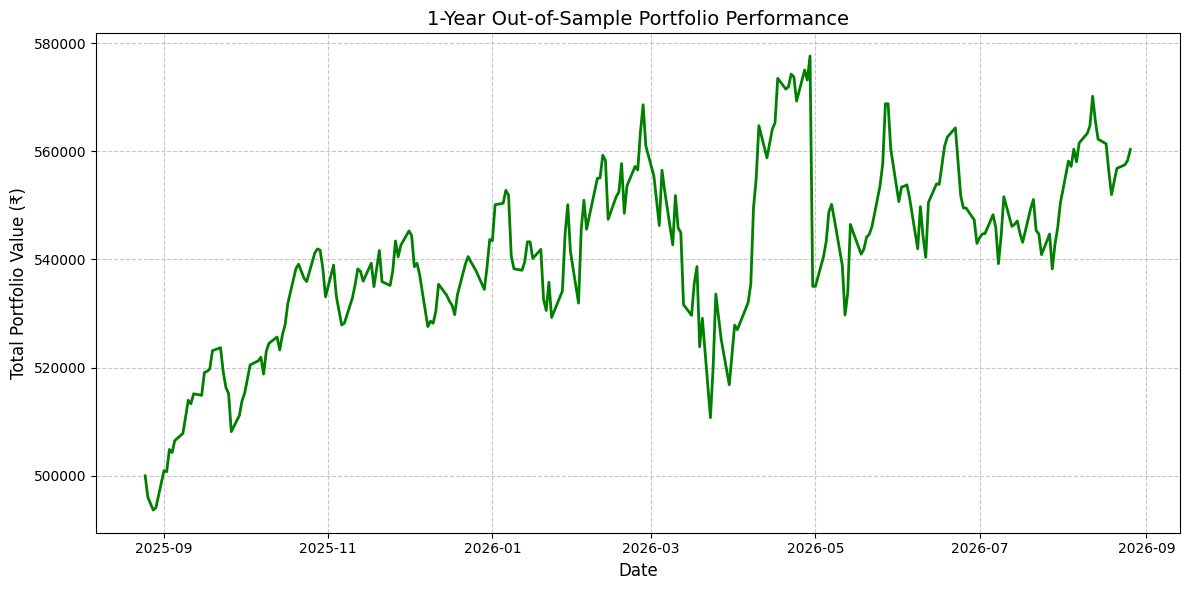

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1-Year Portfolio Backtest & Visualization
# ==========================================================
backtest_results = []
portfolio_return = 0
capital = 500000

# Create a Series to track the daily portfolio value
first_ticker = weights_df.index[0]
daily_portfolio_value = pd.Series(0.0, index=test_data[first_ticker].index)

for ticker in weights_df.index:
    weight = weights_df.loc[ticker, "Weight"]
    
    # 1. Grab the full 1-year price history for the test period
    daily_prices = test_data[ticker]["Close"]
    
    # 2. Extract specific buy and sell prices
    buy_price = daily_prices.iloc[0] 
    sell_price = daily_prices.iloc[-1] 
    
    # 3. Calculate metrics for the DataFrame
    stock_return = (sell_price - buy_price) / buy_price
    weighted_return = weight * stock_return
    portfolio_return += weighted_return
    
    backtest_results.append({
        "Ticker": ticker,
        "Weight": weight,
        "Buy Price": buy_price,
        "Sell Price": sell_price,
        "1-Year Stock Return": stock_return,
        "Weighted Return": weighted_return
    })
    
    # 4. Calculate daily trajectory for the plot
    normalized_returns = daily_prices / buy_price
    daily_investment_value = normalized_returns * weight * capital
    daily_portfolio_value += daily_investment_value

# Format and display the breakdown table
backtest_df = pd.DataFrame(backtest_results).sort_values("Weight", ascending=False)
display(backtest_df)

# Extract final metrics
final_value = daily_portfolio_value.iloc[-1]
total_return_pct = ((final_value - capital) / capital) * 100

# Display Metrics
print("\n=========================================")
print(f"Initial Capital:      ₹{capital:,.2f}")
print(f"Final Value (1 Year): ₹{final_value:,.2f}")
print(f"ACTUAL 1-YEAR RETURN: {total_return_pct:.2f}%")
print("=========================================\n")

# Plot the 1-year performance
plt.figure(figsize=(12, 6))
plt.plot(daily_portfolio_value.index, daily_portfolio_value.values, color='green', linewidth=2)
plt.title("1-Year Out-of-Sample Portfolio Performance", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Portfolio Value (₹)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [52]:
count = (portfolio['Weight']).sum()

In [53]:
count

np.float64(1.0)

,Ticker,Target Weight,Buy Price,Shares,Actual Investment,Sell Price,P&L (₹),Stock Return,Weighted Return
0,HINDUNILVR.NS,0.10719,2584.782959,20,51695.659180,2021.000000,-11275.659180,-0.218116,-0.023380
1,CIPLA.NS,0.09432,1586.317871,29,46003.218262,1402.699951,-5324.919678,-0.115751,-0.010918
2,HEROMOTOCO.NS,0.08952,4894.984375,9,44054.859375,5595.000000,6300.140625,0.143007,0.012802
3,EICHERMOT.NS,0.08925,5928.418457,7,41498.929199,8035.000000,14746.070801,0.355336,0.031714
4,BHARTIARTL.NS,0.07786,1906.703613,20,38134.072266,1902.099976,-92.072754,-0.002414,-0.000188
5,ZYDUSLIFE.NS,0.07749,1022.231445,37,37822.563477,1150.000000,4727.436523,0.124990,0.009685
6,INDIANB.NS,0.06840,654.115540,52,34014.008057,889.000000,12213.991943,0.359087,0.024562
7,VEDL.NS,0.05966,427.165955,69,29474.450867,286.500000,-9705.950867,-0.329300,-0.019646
8,CUMMINSIND.NS,0.05775,3831.157959,7,26818.105713,5200.000000,9581.894287,0.357292,0.020634
9,MOTILALOFS.NS,0.04503,918.288025,24,22038.912598,1040.000000,2921.087402,0.132542,0.005968



Initial Capital:        ₹500,000.00
Actually Invested:      ₹484,870.36
Uninvested Cash:        ₹15,129.64
Final Value (1 Year):   ₹559,084.54
ACTUAL 1-YEAR RETURN:   11.82%



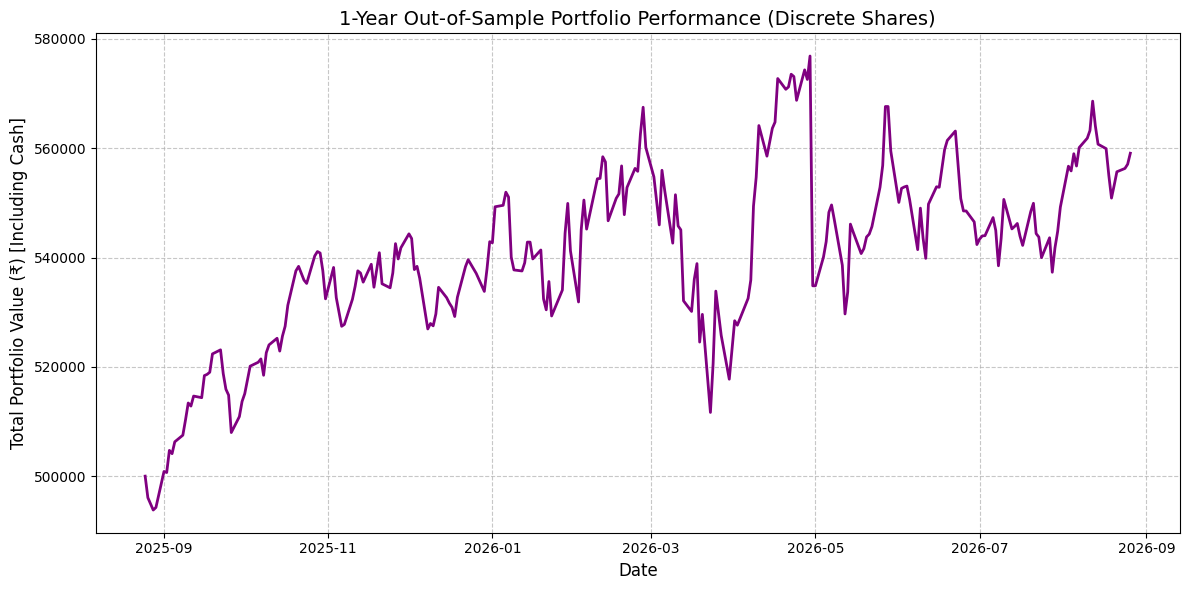

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1-Year Discrete (Actual Shares) Portfolio Backtest
# ==========================================================
backtest_results = []
capital = 500000
total_actual_invested = 0

# Create a Series to track the daily value of the INVESTED portion
first_ticker = weights_df.index[0]
daily_invested_value = pd.Series(0.0, index=test_data[first_ticker].index)

for ticker in weights_df.index:
    weight = weights_df.loc[ticker, "Weight"]
    
    # 1. Grab the full 1-year price history for the test period
    daily_prices = test_data[ticker]["Close"]
    
    # 2. Extract specific buy and sell prices
    buy_price = daily_prices.iloc[0] 
    sell_price = daily_prices.iloc[-1] 
    
    # 3. Calculate ACTUAL SHARES (rounding down to nearest whole number)
    theoretical_investment = weight * capital
    shares_to_buy = int(theoretical_investment / buy_price)
    
    # 4. Calculate actual monetary investment
    actual_investment = shares_to_buy * buy_price
    total_actual_invested += actual_investment
    
    # 5. Calculate Profit/Loss for this specific stock
    actual_sell_value = shares_to_buy * sell_price
    profit_loss = actual_sell_value - actual_investment
    stock_return = (sell_price - buy_price) / buy_price if buy_price > 0 else 0
    
    backtest_results.append({
        "Ticker": ticker,
        "Target Weight": weight,
        "Buy Price": buy_price,
        "Shares": shares_to_buy,
        "Actual Investment": actual_investment,
        "Sell Price": sell_price,
        "P&L (₹)": profit_loss,
        "Stock Return": stock_return,
        "Weighted Return": weight * stock_return
    })
    
    # 6. Calculate daily trajectory using ACTUAL SHARES
    daily_stock_value = daily_prices * shares_to_buy
    daily_invested_value += daily_stock_value

# Account for uninvested cash (capital that couldn't buy a full share)
leftover_cash = capital - total_actual_invested
daily_total_portfolio_value = daily_invested_value + leftover_cash

# Format and display the breakdown table
backtest_df = pd.DataFrame(backtest_results).sort_values("Actual Investment", ascending=False)
display(backtest_df)

# Extract final metrics
final_portfolio_value = daily_total_portfolio_value.iloc[-1]
total_return_pct = ((final_portfolio_value - capital) / capital) * 100

# Display Metrics
print("\n=========================================")
print(f"Initial Capital:        ₹{capital:,.2f}")
print(f"Actually Invested:      ₹{total_actual_invested:,.2f}")
print(f"Uninvested Cash:        ₹{leftover_cash:,.2f}")
print(f"Final Value (1 Year):   ₹{final_portfolio_value:,.2f}")
print(f"ACTUAL 1-YEAR RETURN:   {total_return_pct:.2f}%")
print("=========================================\n")

# Plot the 1-year performance
plt.figure(figsize=(12, 6))
plt.plot(daily_total_portfolio_value.index, daily_total_portfolio_value.values, color='purple', linewidth=2)
plt.title("1-Year Out-of-Sample Portfolio Performance (Discrete Shares)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Portfolio Value (₹) [Including Cash]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [55]:
(backtest_df['Weighted Return']).sum()

np.float64(0.12061989366337597)

In [56]:
sample = yf.Ticker("RELIANCE.NS")
print(sample.quarterly_income_stmt.columns)   # column headers are period-end dates

DatetimeIndex(['2026-06-30', '2026-03-31', '2025-12-31', '2025-06-30', '2025-03-31'], dtype='datetime64[ns]', freq=None)


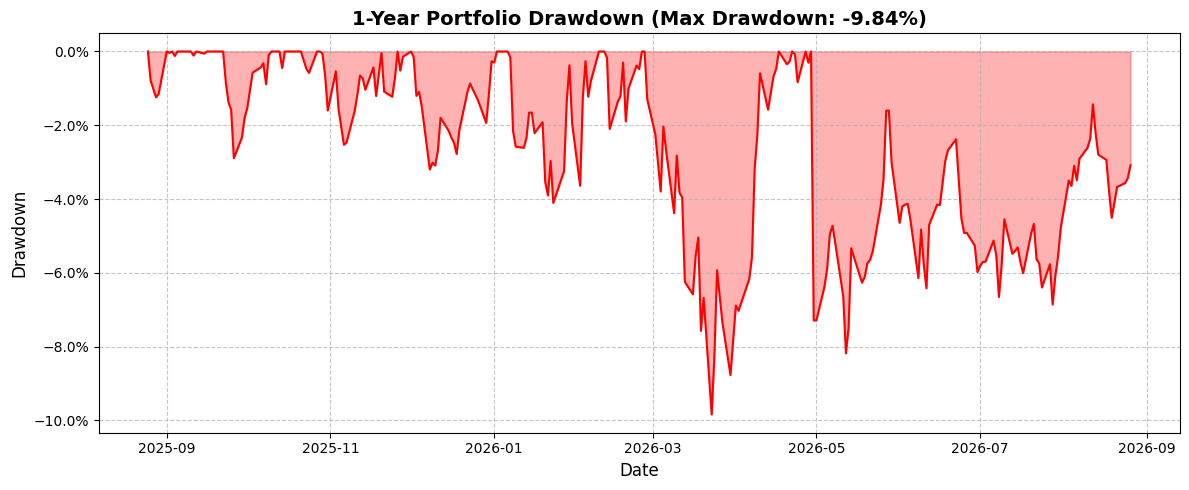

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ==========================================================
# Drawdown Calculation & Visualization
# ==========================================================

# 1. Calculate the historical running maximum (the peak)
rolling_peak = daily_total_portfolio_value.cummax()

# 2. Calculate the daily drawdown percentage
daily_drawdown = (daily_total_portfolio_value - rolling_peak) / rolling_peak

# 3. Find the Maximum Drawdown (the deepest valley)
max_drawdown = daily_drawdown.min()

# 4. Plot the Drawdown
plt.figure(figsize=(12, 5))

# Fill the area under the curve in red to emphasize the "pain" of the drawdown
plt.fill_between(
    daily_drawdown.index, 
    daily_drawdown.values, 
    0, 
    color='red', 
    alpha=0.3
)
plt.plot(daily_drawdown.index, daily_drawdown.values, color='red', linewidth=1.5)

# Formatting
plt.title(f"1-Year Portfolio Drawdown (Max Drawdown: {max_drawdown * 100:.2f}%)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Drawdown", fontsize=12)

# Format the Y-axis as percentages (e.g., -5%, -10%)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) 

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [59]:
train_data['360ONE.NS']["Close"].iloc[-1]

np.float64(1069.9158935546875)